# CTCF Pattern Analysis
Compares CTCF motif distributions across three sequences:
- **Initial** – the original genomic sequence before optimisation
- **Optimised** – the sequence produced by Ledidi
- **Target** – the target genomic region

In [1]:
import os
import sys
import numpy as np
import torch
import pandas as pd
import matplotlib.pyplot as plt
from pyfaidx import Fasta

In [2]:
# Project root → gives access to utils/
PROJECT_ROOT = os.path.abspath("/home1/smaruj/akita_semifreddo")
sys.path.insert(0, PROJECT_ROOT)

from utils.fimo_utils import read_meme_pwm, run_fimo, ctcf_hits_from_fimo
from utils.plot_utils import plot_ctcf_track

## Parameters
Edit the variables in this cell to point to your data.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────
FOLD          = 0
BASE_DIR      = "/project2/fudenber_735/smaruj/sequence_design/ledidi_semifreddo_akita/optimizations/genome_rewiring"
CTCF_PWM_PATH = "/home1/smaruj/akita_semifreddo/data/pwm/MA0139.1.meme"
PLOTS_DIR = os.path.join(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))), "plots")

# ── Sequence coordinates: the ORIGINAL region ───────────────────────────────
ORIG_CHROM = "chr3"
ORIG_START = 138672128
ORIG_END   = 139982848

# ── Sequence coordinates: the TARGET region ───────────────────────────────
TARGET_CHROM = "chr5"
TARGET_START = 43542528
TARGET_END   = 44853248

# ── target, initial and optimised sequences ───────────────────────────────
SEQ_INIT_PATH  = f"{BASE_DIR}/ohe_X_fold0/{ORIG_CHROM}_{ORIG_START}_{ORIG_END}_X.pt"
TARGET_CHROM_PATH  = f"{BASE_DIR}/ohe_X_fold0/{TARGET_CHROM}_{TARGET_START}_{TARGET_END}_X.pt"
SEQ_FINAL_PATH = f"{BASE_DIR}/results_fold0/{ORIG_CHROM}_{ORIG_START}_{ORIG_END}_seq.pt"

# ── FIMO parameters ───────────────────────────────────────────────────────
FIMO_THRESHOLD = 1e-4

# ── Genomic binning (must match Akita v2 settings) ────────────────────────
SEQ_LEN  = 1_310_720   # full input length (bp)
BIN_SIZE = 2048        # bp per bin → 640 bins total

os.makedirs(PLOTS_DIR, exist_ok=True)
print(f"Plots will be saved to: {PLOTS_DIR}")

Plots will be saved to: /home1/smaruj/ledidi_akita/optimizations/genome_rewiring/plots


## Load Data

In [4]:
# CTCF PWM
pwm_CTCF   = read_meme_pwm(CTCF_PWM_PATH)
motifs_dict = {"CTCF": pwm_CTCF}

# Ledidi sequences  (1, 4, 1310720)
seq_init  = torch.load(SEQ_INIT_PATH,  weights_only=True)
seq_final = torch.load(SEQ_FINAL_PATH, weights_only=True)
seq_target = torch.load(TARGET_CHROM_PATH, weights_only=True)

print(f"Initial sequence shape : {tuple(seq_init.shape)}")
print(f"Optimised sequence shape: {tuple(seq_final.shape)}")
print(f"Target sequence shape  : {tuple(seq_target.shape)}")

Initial sequence shape : (1, 4, 1310720)
Optimised sequence shape: (1, 4, 1310720)
Target sequence shape  : (1, 4, 1310720)


## CTCF Motif Scanning (FIMO)
Scans all three sequences for CTCF binding sites at p < `FIMO_THRESHOLD`.

In [5]:
hits_init   = run_fimo(seq_init,   motifs_dict, FIMO_THRESHOLD)
hits_final  = run_fimo(seq_final,  motifs_dict, FIMO_THRESHOLD)
hits_target = run_fimo(seq_target, motifs_dict, FIMO_THRESHOLD)

ctcf_init_plus,   ctcf_init_minus   = ctcf_hits_from_fimo(hits_init)
ctcf_final_plus,  ctcf_final_minus  = ctcf_hits_from_fimo(hits_final)
ctcf_target_plus, ctcf_target_minus = ctcf_hits_from_fimo(hits_target)

print(f"Initial  – CTCF hits: {int(ctcf_init_plus.sum() + ctcf_init_minus.sum())}")
print(f"Optimised – CTCF hits: {int(ctcf_final_plus.sum() + ctcf_final_minus.sum())}")
print(f"Target   – CTCF hits: {int(ctcf_target_plus.sum() + ctcf_target_minus.sum())}")

Initial  – CTCF hits: 237
Optimised – CTCF hits: 273
Target   – CTCF hits: 294


## CTCF Tracks
Black bars = + strand hits, red bars = − strand hits.

Saved: /home1/smaruj/ledidi_akita/optimizations/genome_rewiring/plots/ctcf_initial.svg


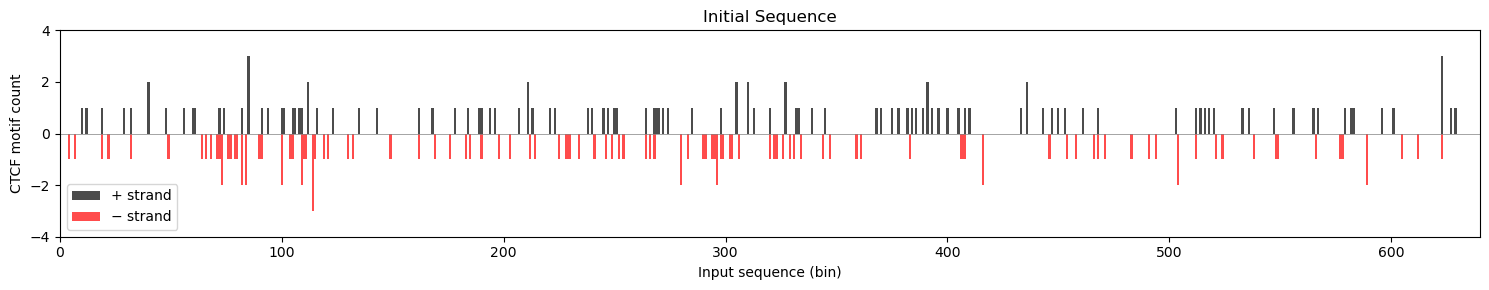

Saved: /home1/smaruj/ledidi_akita/optimizations/genome_rewiring/plots/ctcf_optimised.svg


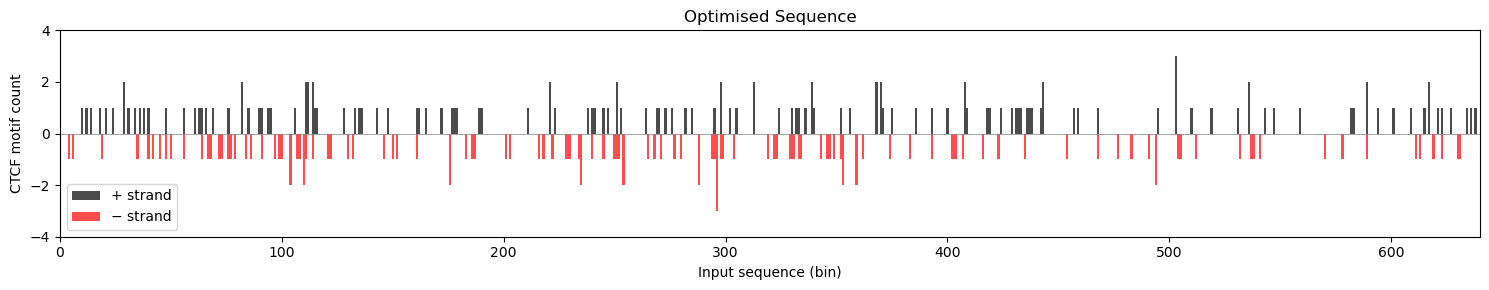

Saved: /home1/smaruj/ledidi_akita/optimizations/genome_rewiring/plots/ctcf_target.svg


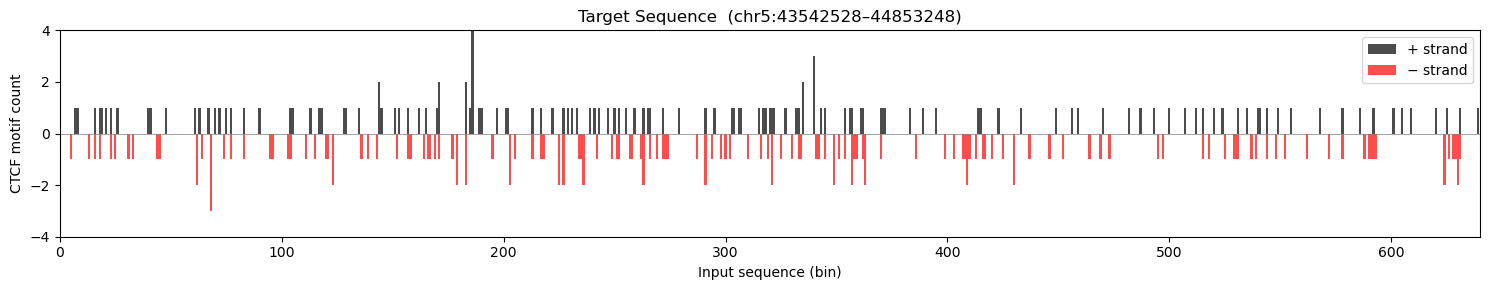

In [6]:
plot_ctcf_track(
    ctcf_init_plus, ctcf_init_minus,
    title="Initial Sequence",
    save_path=os.path.join(PLOTS_DIR, "ctcf_initial.svg")
)

plot_ctcf_track(
    ctcf_final_plus, ctcf_final_minus,
    title="Optimised Sequence",
    save_path=os.path.join(PLOTS_DIR, "ctcf_optimised.svg")
)

plot_ctcf_track(
    ctcf_target_plus, ctcf_target_minus,
    title=f"Target Sequence  ({TARGET_CHROM}:{TARGET_START}–{TARGET_END})",
    save_path=os.path.join(PLOTS_DIR, "ctcf_target.svg")
)